# MarketMinds — Phase 1: Data Pipeline

Builds the master historical dataset for the NIFTY 50 index, SENSEX, a sector-diversified basket of NSE stocks, gold (via GOLDBEES.NS), and India VIX — roughly 2000-2025.

Pipeline steps:
1. Download Kaggle baseline datasets (bootstraps 2000-2021 history)
2. Load & inspect both Kaggle datasets, check overlap
3. Pull live data via yfinance (indices, stock basket, gold proxy, VIX) to extend to today
4. Merge/reconcile Kaggle history with yfinance data per symbol
5. Handle missing values / trading gaps
6. Feature engineering (returns, moving averages, RSI, MACD, rolling volatility)
7. Load any supplementary manually-placed gold/VIX files (optional — primary source is yfinance from step 3)
8. Tag event windows (2008 crisis, COVID crash)
9. Save the cleaned master dataset to `data/processed/` as Parquet

**Note on execution**: every cell below is meant to be run by you, in order. If a cell errors, paste the traceback back and it'll get fixed here — nothing in this notebook gets executed on your behalf.

## Setup

In [1]:
import glob
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)

# Project paths (notebook lives in notebooks/, data lives in ../data/)
PROJECT_ROOT = Path('..').resolve()
RAW_DIR = PROJECT_ROOT / 'data' / 'raw'
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'

KAGGLE_2021_DIR = RAW_DIR / 'kaggle_nifty50_2000_2021'
KAGGLE_2025_DIR = RAW_DIR / 'kaggle_nifty50_2000_2025'
YFINANCE_DIR = RAW_DIR / 'yfinance'
GOLD_MANUAL_DIR = RAW_DIR / 'gold'
VIX_MANUAL_DIR = RAW_DIR / 'vix'

for d in [KAGGLE_2021_DIR, KAGGLE_2025_DIR, YFINANCE_DIR, GOLD_MANUAL_DIR, VIX_MANUAL_DIR, PROCESSED_DIR]:
    d.mkdir(parents=True, exist_ok=True)


def ensure_naive(date_series):
    """Parse to datetime and strip any timezone, so every date column in this
    notebook is directly comparable regardless of which source it came from
    (yfinance returns tz-aware Asia/Kolkata timestamps; Kaggle CSVs are naive)."""
    parsed = pd.to_datetime(date_series)
    if getattr(parsed.dt, 'tz', None) is not None:
        parsed = parsed.dt.tz_localize(None)
    return parsed


print('Project root:', PROJECT_ROOT)

Project root: /Users/palakjagtap/Documents/Market_minds


## 1. Download Kaggle datasets

Two datasets, used together:
- `rohanrao/nifty50-stock-market-data` — per-stock daily CSVs, 2000-2021. This is the well-established one that bootstraps the deep history.
- `ashishjangra27/nifty-50-25-yrs-data` — 2000-2025, used to fill the 2021-2025 gap in case yfinance has any coverage issues, and as a cross-check.

These cells use `!`, so they run inside the notebook using your already-authenticated `kaggle` CLI. Nothing downloads until you run them.

In [2]:
!kaggle datasets download -d rohanrao/nifty50-stock-market-data -p ../data/raw/kaggle_nifty50_2000_2021 --unzip

Dataset URL: https://www.kaggle.com/datasets/rohanrao/nifty50-stock-market-data
License(s): CC0-1.0
100%|█████████████████████████████████████| 18.4M/18.4M [00:03<00:00, 6.40MB/s]



In [3]:
!kaggle datasets download -d ashishjangra27/nifty-50-25-yrs-data -p ../data/raw/kaggle_nifty50_2000_2025 --unzip

Dataset URL: https://www.kaggle.com/datasets/ashishjangra27/nifty-50-25-yrs-data
License(s): CC0-1.0
100%|██████████████████████████████████████| 90.9k/90.9k [00:00<00:00, 386kB/s]



## 2. Load & inspect both Kaggle datasets

We don't assume the exact file/column layout — list what actually downloaded first, then load and print schema so we catch mismatches before writing merge logic.

In [4]:
print('--- kaggle_nifty50_2000_2021 ---')
files_2021 = sorted(glob.glob(str(KAGGLE_2021_DIR / '**' / '*.csv'), recursive=True))
print(len(files_2021), 'CSV files found')
for f in files_2021[:10]:
    print(' ', Path(f).relative_to(KAGGLE_2021_DIR))
if len(files_2021) > 10:
    print('  ... and', len(files_2021) - 10, 'more')

print()
print('--- kaggle_nifty50_2000_2025 ---')
files_2025 = sorted(glob.glob(str(KAGGLE_2025_DIR / '**' / '*.csv'), recursive=True))
print(len(files_2025), 'CSV files found')
for f in files_2025[:10]:
    print(' ', Path(f).relative_to(KAGGLE_2025_DIR))
if len(files_2025) > 10:
    print('  ... and', len(files_2025) - 10, 'more')

--- kaggle_nifty50_2000_2021 ---
52 CSV files found
  ADANIPORTS.csv
  ASIANPAINT.csv
  AXISBANK.csv
  BAJAJ-AUTO.csv
  BAJAJFINSV.csv
  BAJFINANCE.csv
  BHARTIARTL.csv
  BPCL.csv
  BRITANNIA.csv
  CIPLA.csv
  ... and 42 more

--- kaggle_nifty50_2000_2025 ---
1 CSV files found
  data.csv


In [5]:
# rohanrao dataset: one CSV per stock symbol, columns typically
# Date, Symbol, Series, Prev Close, Open, High, Low, Last, Close, VWAP, Volume, Turnover, Trades, Deliverable Volume, %Deliverble

def load_rohanrao_dataset(files):
    frames = []
    for f in files:
        symbol = Path(f).stem.upper()
        if symbol.lower() in ('stock_metadata',):
            continue
        df = pd.read_csv(f)
        df.columns = [c.strip() for c in df.columns]
        if 'Date' not in df.columns or 'Close' not in df.columns:
            print('  skipping', symbol, ': unexpected columns', list(df.columns))
            continue
        df['Date'] = ensure_naive(df['Date'])
        df['Symbol'] = symbol
        df['source'] = 'kaggle_2021'
        frames.append(df)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

kaggle_2021_raw = load_rohanrao_dataset(files_2021)
print('Shape:', kaggle_2021_raw.shape)
print('Columns:', list(kaggle_2021_raw.columns))
print('Symbols:', kaggle_2021_raw['Symbol'].nunique() if not kaggle_2021_raw.empty else 0)
print('Date range:', kaggle_2021_raw['Date'].min(), '->', kaggle_2021_raw['Date'].max())
kaggle_2021_raw.head()

Shape: (470384, 16)
Columns: ['Date', 'Symbol', 'Series', 'Prev Close', 'Open', 'High', 'Low', 'Last', 'Close', 'VWAP', 'Volume', 'Turnover', 'Trades', 'Deliverable Volume', '%Deliverble', 'source']
Symbols: 50
Date range: 2000-01-03 00:00:00 -> 2021-04-30 00:00:00


,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble,source
0,2007-11-27,ADANIPORTS,EQ,440.0,770.0,1050.0,770.0,959.0,962.9,984.72,27294366,2687719053785000.0,NaN,9859619,0.3612,kaggle_2021
1,2007-11-28,ADANIPORTS,EQ,962.9,984.0,990.0,874.0,885.0,893.9,941.38,4581338,431276530164999.9375,NaN,1453278,0.3172,kaggle_2021
2,2007-11-29,ADANIPORTS,EQ,893.9,909.0,914.75,841.0,887.0,884.2,888.09,5124121,455065846264999.9375,NaN,1069678,0.2088,kaggle_2021
3,2007-11-30,ADANIPORTS,EQ,884.2,890.0,958.0,890.0,929.0,921.55,929.17,4609762,428325662830000.0,NaN,1260913,0.2735,kaggle_2021
4,2007-12-03,ADANIPORTS,EQ,921.55,939.75,995.0,922.0,980.0,969.3,965.65,2977470,287519974300000.0,NaN,816123,0.2741,kaggle_2021


In [6]:
# We haven't verified this dataset's exact column names/layout — this loader
# auto-detects common variants. If it prints a warning below, paste the actual
# columns back and the DATE/SYMBOL/CLOSE alias lists below get adjusted.

DATE_ALIASES = ['Date', 'date', 'Datetime']
SYMBOL_ALIASES = ['Symbol', 'symbol', 'Ticker', 'Stock', 'stock']
CLOSE_ALIASES = ['Close', 'close', 'Close Price', 'ClosePrice']

def find_col(columns, aliases):
    for a in aliases:
        if a in columns:
            return a
    return None

def load_ashishjangra_dataset(files):
    frames = []
    for f in files:
        df = pd.read_csv(f)
        df.columns = [c.strip() for c in df.columns]
        date_col = find_col(df.columns, DATE_ALIASES)
        if date_col is None:
            print('  ', Path(f).name, ': no recognizable date column, columns =', list(df.columns))
            continue
        symbol_col = find_col(df.columns, SYMBOL_ALIASES)
        if symbol_col is None:
            # single-symbol-per-file layout: use filename as symbol
            df['Symbol'] = Path(f).stem.upper()
        else:
            df = df.rename(columns={symbol_col: 'Symbol'})
        df = df.rename(columns={date_col: 'Date'})
        df['Date'] = ensure_naive(df['Date'])
        df['source'] = 'kaggle_2025'
        frames.append(df)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

kaggle_2025_raw = load_ashishjangra_dataset(files_2025)
print('Shape:', kaggle_2025_raw.shape)
print('Columns:', list(kaggle_2025_raw.columns))
if not kaggle_2025_raw.empty:
    print('Symbols:', kaggle_2025_raw['Symbol'].nunique())
    print('Date range:', kaggle_2025_raw['Date'].min(), '->', kaggle_2025_raw['Date'].max())
kaggle_2025_raw.head()

Shape: (6315, 7)
Columns: ['Date', 'Open', 'High', 'Low', 'Close', 'Symbol', 'source']
Symbols: 1
Date range: 2000-01-03 00:00:00 -> 2025-05-26 00:00:00


,Date,Open,High,Low,Close,Symbol,source
0,2000-01-03,1482.15,1592.90,1482.15,1592.2,DATA,kaggle_2025
1,2000-01-04,1594.40,1641.95,1594.40,1638.7,DATA,kaggle_2025
2,2000-01-05,1634.55,1635.50,1555.05,1595.8,DATA,kaggle_2025
3,2000-01-06,1595.80,1639.00,1595.80,1617.6,DATA,kaggle_2025
4,2000-01-07,1616.60,1628.25,1597.20,1613.3,DATA,kaggle_2025


In [7]:
close_col_2021 = 'Close'
close_col_2025 = find_col(kaggle_2025_raw.columns, CLOSE_ALIASES) if not kaggle_2025_raw.empty else None
print('Close column used for 2025 dataset:', close_col_2025)

common_symbols = sorted(set(kaggle_2021_raw['Symbol']) & set(kaggle_2025_raw['Symbol'])) if not kaggle_2025_raw.empty else []
print(len(common_symbols), 'symbols in common out of', kaggle_2021_raw['Symbol'].nunique(), '(2021 set) /', (kaggle_2025_raw['Symbol'].nunique() if not kaggle_2025_raw.empty else 0), '(2025 set)')

if common_symbols and close_col_2025:
    sample_symbol = common_symbols[0]
    a = kaggle_2021_raw[kaggle_2021_raw['Symbol'] == sample_symbol].set_index('Date')[close_col_2021]
    b = kaggle_2025_raw[kaggle_2025_raw['Symbol'] == sample_symbol].set_index('Date')[close_col_2025]
    overlap_dates = a.index.intersection(b.index)
    print('Sample symbol:', sample_symbol, ',', len(overlap_dates), 'overlapping dates')
    if len(overlap_dates) > 0:
        diff_pct = ((a.loc[overlap_dates] - b.loc[overlap_dates]) / a.loc[overlap_dates] * 100).abs()
        print('Max abs % diff on overlapping dates:', diff_pct.max())
        print('Mean abs % diff on overlapping dates:', diff_pct.mean())

Close column used for 2025 dataset: Close
0 symbols in common out of 50 (2021 set) / 1 (2025 set)


## 3. Pull live data via yfinance

Basket: NIFTY 50 and SENSEX indices, a sector-diversified set of 19 NIFTY 50 stocks (so the "concentrated vs diversified" lesson has real sector contrast), gold via the GOLDBEES.NS ETF (as agreed — real INR-traded proxy, history from ~2007), and India VIX. Edit `STOCK_BASKET` below if you want a different set of names before running.

In [8]:
INDICES = {
    '^NSEI': 'Index',
    '^BSESN': 'Index',
}

STOCK_BASKET = {
    'RELIANCE.NS': 'Energy',
    'ONGC.NS': 'Energy',
    'TCS.NS': 'IT',
    'INFY.NS': 'IT',
    'WIPRO.NS': 'IT',
    'HDFCBANK.NS': 'Financials',
    'ICICIBANK.NS': 'Financials',
    'SBIN.NS': 'Financials',
    'KOTAKBANK.NS': 'Financials',
    'HINDUNILVR.NS': 'FMCG',
    'ITC.NS': 'FMCG',
    'NESTLEIND.NS': 'FMCG',
    'SUNPHARMA.NS': 'Pharma',
    'DRREDDY.NS': 'Pharma',
    'MARUTI.NS': 'Auto',
    'TATAMOTORS.NS': 'Auto',
    'TATASTEEL.NS': 'Metals',
    'LT.NS': 'Infra',
    'ULTRACEMCO.NS': 'Cement',
}

OTHER_ASSETS = {
    'GOLDBEES.NS': 'Gold',
    '^INDIAVIX': 'Volatility',
}

ALL_TICKERS = {**INDICES, **STOCK_BASKET, **OTHER_ASSETS}
print(len(ALL_TICKERS), 'tickers total:', len(INDICES), 'indices,', len(STOCK_BASKET), 'stocks,', len(OTHER_ASSETS), 'other')

23 tickers total: 2 indices, 19 stocks, 2 other


In [9]:
import time

START_DATE = '2000-01-01'
yfinance_frames = {}
failed_tickers = []

def safe_filename(ticker):
    return ticker.replace('^', 'IDX_')

for ticker, category in ALL_TICKERS.items():
    try:
        hist = yf.Ticker(ticker).history(start=START_DATE, auto_adjust=False)
        if hist.empty:
            failed_tickers.append(ticker)
            continue
        hist = hist.reset_index()
        hist['Date'] = ensure_naive(hist['Date'])
        hist['Ticker'] = ticker
        hist['category'] = category
        yfinance_frames[ticker] = hist
        out_path = YFINANCE_DIR / (safe_filename(ticker) + '.csv')
        hist.to_csv(out_path, index=False)
        print(ticker, ':', len(hist), 'rows,', hist['Date'].min().date(), '->', hist['Date'].max().date())
    except Exception as e:
        print(ticker, ': FAILED —', e)
        failed_tickers.append(ticker)
    time.sleep(0.5)

print()
print(len(yfinance_frames), 'succeeded,', len(failed_tickers), 'failed:', failed_tickers)

^NSEI : 4636 rows, 2007-09-17 -> 2026-08-11
^BSESN : 6559 rows, 2000-01-03 -> 2026-08-11
RELIANCE.NS : 6638 rows, 2000-01-03 -> 2026-08-11
ONGC.NS : 6638 rows, 2000-01-03 -> 2026-08-11
TCS.NS : 5959 rows, 2002-08-12 -> 2026-08-11
INFY.NS : 6641 rows, 2000-01-03 -> 2026-08-11
WIPRO.NS : 6641 rows, 2000-01-03 -> 2026-08-11
HDFCBANK.NS : 6641 rows, 2000-01-03 -> 2026-08-11
ICICIBANK.NS : 5988 rows, 2002-07-01 -> 2026-08-11


$SBIN.NS: possibly delisted; no price data found  (1d 2000-01-01 -> 2026-08-11)


KOTAKBANK.NS : 6250 rows, 2001-07-02 -> 2026-08-11
HINDUNILVR.NS : 6641 rows, 2000-01-03 -> 2026-08-11
ITC.NS : 6638 rows, 2000-01-03 -> 2026-08-11
NESTLEIND.NS : 5961 rows, 2002-08-12 -> 2026-08-11
SUNPHARMA.NS : 6640 rows, 2000-01-03 -> 2026-08-11
DRREDDY.NS : 6638 rows, 2000-01-03 -> 2026-08-11
MARUTI.NS : 5723 rows, 2003-07-09 -> 2026-08-11


HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: TATAMOTORS.NS"}}}
$TATAMOTORS.NS: possibly delisted; no timezone found


TATASTEEL.NS : 6641 rows, 2000-01-03 -> 2026-08-11
LT.NS : 5991 rows, 2002-07-01 -> 2026-08-11
ULTRACEMCO.NS : 5958 rows, 2002-08-12 -> 2026-08-11
GOLDBEES.NS : 4341 rows, 2009-01-02 -> 2026-08-11
^INDIAVIX : 4517 rows, 2008-03-03 -> 2026-08-11

21 succeeded, 2 failed: ['SBIN.NS', 'TATAMOTORS.NS']


In [10]:
yfinance_combined = pd.concat(yfinance_frames.values(), ignore_index=True)
print('Combined shape:', yfinance_combined.shape)
yfinance_combined.groupby('Ticker')['Date'].agg(['min', 'max', 'count'])

Combined shape: (128280, 11)


,min,max,count
Ticker,,,
DRREDDY.NS,2000-01-03,2026-08-11,6638
GOLDBEES.NS,2009-01-02,2026-08-11,4341
HDFCBANK.NS,2000-01-03,2026-08-11,6641
HINDUNILVR.NS,2000-01-03,2026-08-11,6641
ICICIBANK.NS,2002-07-01,2026-08-11,5988
INFY.NS,2000-01-03,2026-08-11,6641
ITC.NS,2000-01-03,2026-08-11,6638
KOTAKBANK.NS,2001-07-02,2026-08-11,6250
LT.NS,2002-07-01,2026-08-11,5991


## 4. Merge/reconcile Kaggle historical data with yfinance data

**Final decision: yfinance only, Kaggle is not blended in at all.** Two attempts at combining the sources both introduced artifacts: a fixed 2021 cutover date created a fake cliff at Reliance's 2009 bonus issue (Kaggle isn't split-adjusted); using Kaggle only to fill yfinance's missing dates still pasted occasional unadjusted-scale prices next to adjusted ones, showing up as sharp one-day spikes wherever a gap-fill landed after any historical split. Since yfinance's own pull already gives continuous, consistently split-adjusted coverage for every ticker in the basket, the safest choice is to use it exclusively — any sparse remaining gaps are handled by Step 5's same-scale forward-fill instead of a cross-source patch. Kaggle's role is now limited to the independent cross-check already done in Step 2, not the final dataset.

In [11]:
def reconcile_symbol(ticker, category):
    yf_df = yfinance_frames.get(ticker)
    if yf_df is None:
        return None

    combined = yf_df[['Date', 'Open', 'High', 'Low', 'Close', 'Volume']].copy()
    combined['source'] = 'yfinance'
    combined = combined.sort_values('Date').drop_duplicates(subset='Date', keep='first').reset_index(drop=True)
    combined['Ticker'] = ticker
    combined['category'] = category
    return combined

reconciled = {}
for ticker, category in ALL_TICKERS.items():
    result = reconcile_symbol(ticker, category)
    if result is not None:
        reconciled[ticker] = result

print('Reconciled', len(reconciled), 'tickers')
sample = list(reconciled.keys())[0]
reconciled[sample]['source'].value_counts()

Reconciled 21 tickers


source
yfinance    4636
Name: count, dtype: int64

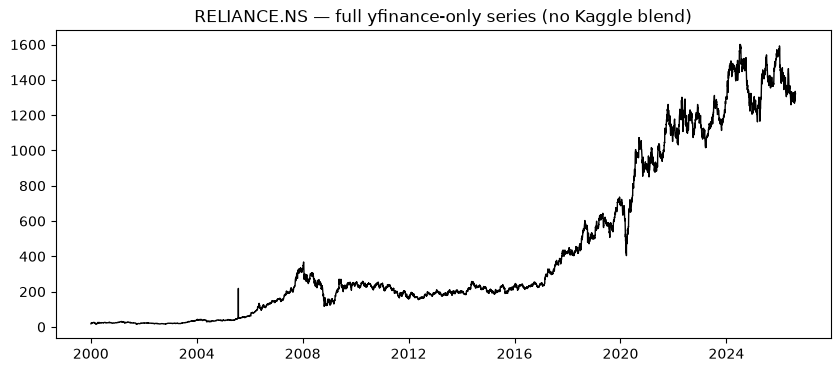

RELIANCE.NS row count: 6638
Any gaps in trading days? Checked in Step 5.


In [12]:
check_ticker = 'RELIANCE.NS'
df_check = reconciled[check_ticker]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(df_check['Date'], df_check['Close'], linewidth=1, color='black')
ax.set_title(check_ticker + ' — full yfinance-only series (no Kaggle blend)')
plt.show()

print(check_ticker, 'row count:', len(df_check))
print('Any gaps in trading days? Checked in Step 5.')

## 5. Handle missing values / trading gaps

We don't reindex to an external NSE holiday calendar (extra dependency, marginal value at daily granularity) — instead we look for gaps between consecutive trading days already present in the data. Short gaps (up to 4 calendar days — a long weekend plus one holiday) get forward-filled. Anything longer is flagged in `gap_report_df` rather than silently filled, since a multi-day gap usually means something real happened (delisting, trading halt, data outage) that shouldn't be papered over.

In [13]:
gap_reports = []

def handle_gaps(df, ticker, max_fill_days=4):
    df = df.sort_values('Date').reset_index(drop=True)
    gap_days = df['Date'].diff().dt.days
    long_gaps = df[gap_days > max_fill_days]
    for idx, row in long_gaps.iterrows():
        gap_reports.append({
            'Ticker': ticker,
            'gap_start': df.loc[idx - 1, 'Date'] if idx > 0 else None,
            'gap_end': row['Date'],
            'gap_days': gap_days.loc[idx],
        })
    # short gaps: forward-fill by reindexing over the missing business days
    full_range = pd.date_range(df['Date'].min(), df['Date'].max(), freq='B')
    df = df.set_index('Date').reindex(full_range)
    df.index.name = 'Date'
    df[['Open', 'High', 'Low', 'Close', 'Volume']] = df[['Open', 'High', 'Low', 'Close', 'Volume']].ffill(limit=max_fill_days)
    df['Ticker'] = ticker
    df = df.dropna(subset=['Close']).reset_index()
    return df

cleaned = {}
for ticker, df in reconciled.items():
    cleaned[ticker] = handle_gaps(df, ticker)

gap_report_df = pd.DataFrame(gap_reports)
print(len(gap_report_df), 'flagged gaps (> 4 calendar days) across all tickers:')
gap_report_df.sort_values('gap_days', ascending=False).head(20) if len(gap_report_df) else gap_report_df

218 flagged gaps (> 4 calendar days) across all tickers:


,Ticker,gap_start,gap_end,gap_days
109,HINDUNILVR.NS,2014-10-01,2014-10-07,6.0
79,HDFCBANK.NS,2014-10-01,2014-10-07,6.0
20,^BSESN,2014-12-24,2014-12-30,6.0
199,GOLDBEES.NS,2014-10-01,2014-10-07,6.0
29,RELIANCE.NS,2014-10-01,2014-10-07,6.0
139,SUNPHARMA.NS,2014-10-01,2014-10-07,6.0
189,ULTRACEMCO.NS,2014-10-01,2014-10-07,6.0
39,ONGC.NS,2014-10-01,2014-10-07,6.0
179,LT.NS,2014-10-01,2014-10-07,6.0
99,KOTAKBANK.NS,2014-10-01,2014-10-07,6.0


## 6. Feature engineering

Daily returns, 20/50/200-day moving averages, RSI(14), MACD(12,26,9), and 20-day rolling volatility (std of daily returns) — computed per ticker.

In [14]:
def compute_rsi(close, window=14):
    delta = close.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.ewm(alpha=1 / window, min_periods=window, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1 / window, min_periods=window, adjust=False).mean()
    rs = avg_gain / avg_loss
    return 100 - (100 / (1 + rs))

def compute_macd(close, fast=12, slow=26, signal=9):
    ema_fast = close.ewm(span=fast, adjust=False).mean()
    ema_slow = close.ewm(span=slow, adjust=False).mean()
    macd_line = ema_fast - ema_slow
    signal_line = macd_line.ewm(span=signal, adjust=False).mean()
    return macd_line, signal_line

def add_features(df):
    df = df.sort_values('Date').reset_index(drop=True)
    df['daily_return'] = df['Close'].pct_change()
    df['ma_20'] = df['Close'].rolling(20).mean()
    df['ma_50'] = df['Close'].rolling(50).mean()
    df['ma_200'] = df['Close'].rolling(200).mean()
    df['rsi_14'] = compute_rsi(df['Close'])
    df['macd'], df['macd_signal'] = compute_macd(df['Close'])
    df['volatility_20d'] = df['daily_return'].rolling(20).std()
    return df

featured = {ticker: add_features(df) for ticker, df in cleaned.items()}
featured[list(featured.keys())[0]].tail()

,Date,Open,High,Low,Close,Volume,source,Ticker,category,daily_return,ma_20,ma_50,ma_200,rsi_14,macd,macd_signal,volatility_20d
4927,2026-08-05,24669.199219,24677.599609,24497.949219,24624.650391,355500.0,yfinance,^NSEI,Index,0.000396,24196.19502,23958.886953,24687.602539,62.063218,147.673610,89.402787,0.006829
4928,2026-08-06,24641.000000,24677.050781,24604.150391,24636.000000,344000.0,yfinance,^NSEI,Index,0.000461,24229.85498,23973.463945,24681.393291,62.302464,159.690669,103.460364,0.006819
4929,2026-08-07,24538.900391,24630.400391,24522.750000,24570.650391,254800.0,yfinance,^NSEI,Index,-0.002653,24248.04248,23993.921953,24675.636045,59.957825,162.072833,115.182857,0.006548
4930,2026-08-10,24581.250000,24620.949219,24511.099609,24583.800781,269500.0,yfinance,^NSEI,Index,0.000535,24266.68252,24017.945977,24669.738301,60.281747,163.141251,124.774536,0.006547
4931,2026-08-11,24575.099609,24576.849609,24429.250000,24437.900391,0.0,yfinance,^NSEI,Index,-0.005935,24285.97500,24037.032969,24663.939551,54.968725,150.480394,129.915708,0.006511


## 7. Gold / India VIX — supplementary manual files (optional)

Gold (`GOLDBEES.NS`) and India VIX (`^INDIAVIX`) are already pulled live via yfinance in Step 3, per the earlier decision — this covers gold from ~2007 onward (GOLDBEES.NS's actual listing date) and VIX from its 2009 inception. This step is only for supplementary files placed manually — e.g. a longer synthetic gold series to backfill 2000-2007, or an alternate VIX source. Drop CSVs into `data/raw/gold/` or `data/raw/vix/` and the cell below will find and print their structure so we can decide together how to merge them in. If nothing's there, it's a no-op and the yfinance data from Step 3 stays as-is.

In [15]:
def inspect_manual_files(directory, label):
    files = sorted(glob.glob(str(directory / '*.csv')))
    if not files:
        print('No manual', label, 'files found in', directory, '— using yfinance data from Step 3.')
        return {}
    found = {}
    for f in files:
        df = pd.read_csv(f)
        print(label, 'file:', Path(f).name)
        print('  columns:', list(df.columns))
        print('  shape:', df.shape)
        found[Path(f).stem] = df
    return found

manual_gold_files = inspect_manual_files(GOLD_MANUAL_DIR, 'gold')
manual_vix_files = inspect_manual_files(VIX_MANUAL_DIR, 'VIX')

No manual gold files found in /Users/palakjagtap/Documents/Market_minds/data/raw/gold — using yfinance data from Step 3.
No manual VIX files found in /Users/palakjagtap/Documents/Market_minds/data/raw/vix — using yfinance data from Step 3.


## 8. Tag event windows

Flags each row against known crisis windows so the app's replay engine and any charts can filter/highlight them directly, rather than recomputing date logic downstream.

In [16]:
EVENT_WINDOWS = [
    ('2008_financial_crisis', '2008-01-01', '2009-03-31'),
    ('covid_crash', '2020-02-20', '2020-04-30'),
]

def tag_events(df):
    df = df.copy()
    df['event_tag'] = 'normal'
    for label, start, end in EVENT_WINDOWS:
        mask = (df['Date'] >= start) & (df['Date'] <= end)
        df.loc[mask, 'event_tag'] = label
    return df

tagged = {ticker: tag_events(df) for ticker, df in featured.items()}
tagged[list(tagged.keys())[0]]['event_tag'].value_counts()

event_tag
normal                   4555
2008_financial_crisis     326
covid_crash                51
Name: count, dtype: int64

## 9. Save processed data as Parquet

**Choice: one combined long-format file** (`marketminds_master.parquet`, with `ticker`/`category` columns to distinguish assets) rather than one file per asset. Reasoning: the app backend and any later Supabase ingestion just need to query by ticker + date range, which a single long table does cleanly with a `WHERE`-style filter — versus juggling 20+ small files and having to know which file has what. At this scale (~20 tickers x ~25 years of daily data), the combined file is still only tens of MB, so there's no real performance cost to keeping it as one file. A companion small `symbol_metadata.parquet` records ticker -> category/sector, useful for the app to build things like sector filters without scanning the full price table.

In [17]:
import pyarrow as pa
import pyarrow.parquet as pq

# Writing via pyarrow directly (instead of df.to_parquet()) sidesteps a known
# pandas/pyarrow bug where re-creating pandas' PyArrowImpl engine mid-session
# tries to re-register the same Arrow extension type twice and raises
# ArrowKeyError: 'A type extension with name pandas.period already defined'.

def save_parquet(df, path):
    table = pa.Table.from_pandas(df, preserve_index=False)
    pq.write_table(table, path)

master = pd.concat(tagged.values(), ignore_index=True)
master = master.rename(columns={'Date': 'date', 'Ticker': 'ticker'})

for col in ['ticker', 'category', 'source', 'event_tag']:
    if col in master.columns:
        master[col] = master[col].astype(str)
master['date'] = pd.to_datetime(master['date'])

master_path = PROCESSED_DIR / 'marketminds_master.parquet'
save_parquet(master, master_path)
print('Saved', len(master), 'rows to', master_path)

symbol_metadata = pd.DataFrame(
    [{'ticker': t, 'category': c} for t, c in ALL_TICKERS.items()]
)
metadata_path = PROCESSED_DIR / 'symbol_metadata.parquet'
save_parquet(symbol_metadata, metadata_path)
print('Saved symbol metadata to', metadata_path)

if len(gap_report_df):
    gap_report_path = PROCESSED_DIR / 'flagged_gaps.csv'
    gap_report_df.to_csv(gap_report_path, index=False)
    print('Saved', len(gap_report_df), 'flagged gaps to', gap_report_path)

Saved 134646 rows to /Users/palakjagtap/Documents/Market_minds/data/processed/marketminds_master.parquet
Saved symbol metadata to /Users/palakjagtap/Documents/Market_minds/data/processed/symbol_metadata.parquet
Saved 218 flagged gaps to /Users/palakjagtap/Documents/Market_minds/data/processed/flagged_gaps.csv


## 10. Sanity checks

Quick verification before trusting this dataset downstream: review the flagged gaps for anything that looks systematically wrong (rather than an expected holiday/IPO-date artifact), round-trip the saved Parquet file to confirm it reads back cleanly, and visually check that the event-window tags line up with a real price chart.

In [18]:
print('Gaps by ticker (sorted, most first):')
print(gap_report_df.groupby('Ticker').size().sort_values(ascending=False))

print()
print('Largest individual gaps:')
gap_report_df.sort_values('gap_days', ascending=False).head(15)

Gaps by ticker (sorted, most first):
Ticker
^BSESN           14
^NSEI            12
^INDIAVIX        12
ONGC.NS          10
WIPRO.NS         10
ULTRACEMCO.NS    10
TCS.NS           10
TATASTEEL.NS     10
SUNPHARMA.NS     10
RELIANCE.NS      10
DRREDDY.NS       10
GOLDBEES.NS      10
MARUTI.NS        10
LT.NS            10
KOTAKBANK.NS     10
ITC.NS           10
INFY.NS          10
ICICIBANK.NS     10
HINDUNILVR.NS    10
HDFCBANK.NS      10
NESTLEIND.NS     10
dtype: int64

Largest individual gaps:


,Ticker,gap_start,gap_end,gap_days
109,HINDUNILVR.NS,2014-10-01,2014-10-07,6.0
79,HDFCBANK.NS,2014-10-01,2014-10-07,6.0
20,^BSESN,2014-12-24,2014-12-30,6.0
199,GOLDBEES.NS,2014-10-01,2014-10-07,6.0
29,RELIANCE.NS,2014-10-01,2014-10-07,6.0
139,SUNPHARMA.NS,2014-10-01,2014-10-07,6.0
189,ULTRACEMCO.NS,2014-10-01,2014-10-07,6.0
39,ONGC.NS,2014-10-01,2014-10-07,6.0
179,LT.NS,2014-10-01,2014-10-07,6.0
99,KOTAKBANK.NS,2014-10-01,2014-10-07,6.0


In [19]:
reloaded = pq.read_table(master_path).to_pandas()

print('Reloaded shape:', reloaded.shape, '(should match the', len(master),
 'rows saved above)')
print('Reloaded dtypes:')
print(reloaded.dtypes)
print()
print('Tickers present:', sorted(reloaded['ticker'].unique()))
print()
print('Rows per ticker (min / max / mean):',
      reloaded.groupby('ticker').size().min(),
      reloaded.groupby('ticker').size().max(),
      round(reloaded.groupby('ticker').size().mean(), 1))

Reloaded shape: (134646, 18) (should match the 134646 rows saved above)
Reloaded dtypes:
date              datetime64[us]
Open                     float64
High                     float64
Low                      float64
Close                    float64
Volume                   float64
source                       str
ticker                       str
category                     str
daily_return             float64
ma_20                    float64
ma_50                    float64
ma_200                   float64
rsi_14                   float64
macd                     float64
macd_signal              float64
volatility_20d           float64
event_tag                    str
dtype: object

Tickers present: ['DRREDDY.NS', 'GOLDBEES.NS', 'HDFCBANK.NS', 'HINDUNILVR.NS', 'ICICIBANK.NS', 'INFY.NS', 'ITC.NS', 'KOTAKBANK.NS', 'LT.NS', 'MARUTI.NS', 'NESTLEIND.NS', 'ONGC.NS', 'RELIANCE.NS', 'SUNPHARMA.NS', 'TATASTEEL.NS', 'TCS.NS', 'ULTRACEMCO.NS', 'WIPRO.NS', '^BSESN', '^INDIAVIX', '^NSEI']

Ro

In [24]:
# Event-window tag counts, overall and for one sample ticker
print('event_tag counts, all tickers combined:')
print(reloaded['event_tag'].value_counts())

print()
sample_ticker = 'MARUTI.NS'
sample = reloaded[reloaded['ticker'] == sample_ticker]
print(f'{sample_ticker} — event_tag date ranges:')
print(sample.groupby('event_tag')['date'].agg(['min', 'max', 'count']))

event_tag counts, all tickers combined:
event_tag
normal                   127036
2008_financial_crisis      6539
covid_crash                1071
Name: count, dtype: int64

MARUTI.NS — event_tag date ranges:
                             min        max  count
event_tag                                         
2008_financial_crisis 2008-01-01 2009-03-31    326
covid_crash           2020-02-20 2020-04-30     51
normal                2003-07-09 2026-08-11   5648


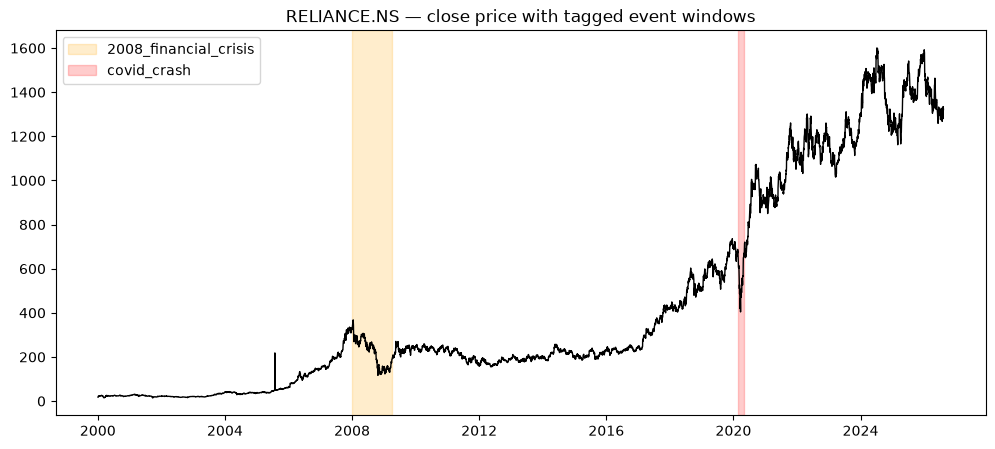

In [21]:
# Visual check: price series for the sample ticker with the 2008 and COVID
# windows shaded, to confirm the tags line up with where the crashes actually are.
sample_ticker = 'MARUTI.NS'
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(sample['date'], sample['close'] if 'close' in sample.columns else sample['Close'], linewidth=1, color='black')

colors = {'2008_financial_crisis': 'orange', 'covid_crash': 'red'}
for label, color in colors.items():
    window = sample[sample['event_tag'] == label]
    if not window.empty:
        ax.axvspan(window['date'].min(), window['date'].max(), color=color, alpha=0.2, label=label)

ax.set_title(sample_ticker + ' — close price with tagged event windows')
ax.legend()
plt.show()

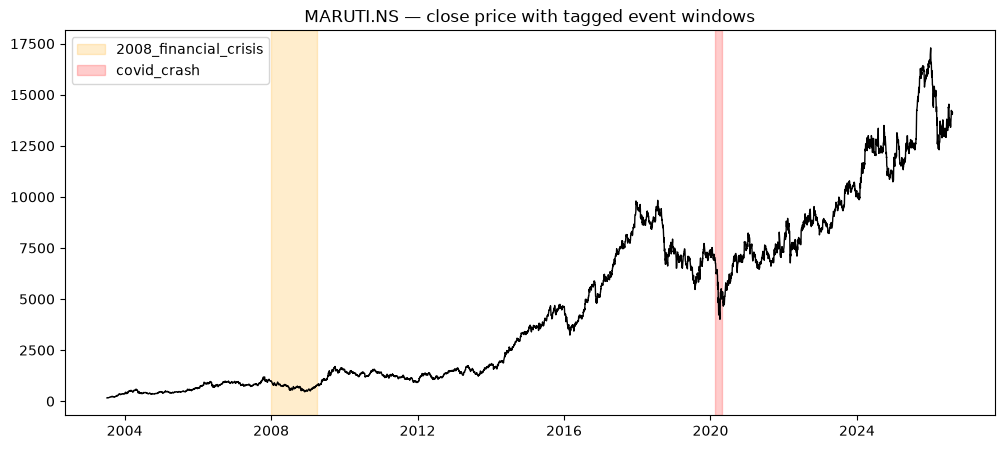

In [25]:
sample_ticker = 'MARUTI.NS'
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(sample['date'], sample['close'] if 'close' in sample.columns else sample['Close'], linewidth=1, color='black')

colors = {'2008_financial_crisis': 'orange', 'covid_crash': 'red'}
for label, color in colors.items():
    window = sample[sample['event_tag'] == label]
    if not window.empty:
        ax.axvspan(window['date'].min(), window['date'].max(), color=color, alpha=0.2, label=label)

ax.set_title(sample_ticker + ' — close price with tagged event windows')
ax.legend()
plt.show()

## Summary

Output of this notebook, in `data/processed/`:
- `marketminds_master.parquet` — long-format table: one row per (ticker, date), with OHLCV, returns, moving averages, RSI, MACD, volatility, and event tags
- `symbol_metadata.parquet` — ticker -> category/sector lookup
- `flagged_gaps.csv` — any data gaps longer than 4 calendar days, for manual review

Next (Phase 2): the backtesting/replay engine that takes a student's allocation across this basket and plays it forward against the real historical data.